In [74]:
import pandas as pd
df = pd.read_csv('stroke_thrombectomy_dataset.csv')
df.head(3)

,patient_id,age,gender,weight_kg,height_cm,bmi,nihss_score,gcs_score,systolic_bp,diastolic_bp,...,number_of_passes,device_used,anesthesia_type,interventionist_experience_years,recanalization_success,mrs_90day,functional_independence,hemorrhagic_transformation,icu_days,mortality_30day
0,ST0001,72,Female,75.1,176.8,24.0,2,8,176,94,...,2,Stent Retriever,General,4.0,1,1,1,0,5,0
1,ST0002,65,Female,55.5,171.5,18.9,39,11,153,98,...,1,Aspiration,General,21.0,1,6,0,0,3,1
2,ST0003,74,Male,98.4,173.7,32.6,12,10,170,76,...,5,Aspiration,Local,23.0,1,2,1,0,18,0


In [75]:
df.columns

Index(['patient_id', 'age', 'gender', 'weight_kg', 'height_cm', 'bmi',
       'nihss_score', 'gcs_score', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'blood_glucose', 'temperature_c', 'oxygen_saturation', 'inr',
       'platelet_count', 'hemoglobin', 'creatinine', 'ldl_cholesterol',
       'hdl_cholesterol', 'triglycerides', 'hba1c', 'clot_location',
       'clot_length_mm', 'aspects_score', 'collateral_score',
       'penumbra_volume_ml', 'core_infarct_volume_ml', 'mismatch_ratio',
       'hypertension', 'diabetes', 'atrial_fibrillation', 'prior_stroke',
       'heart_failure', 'coronary_artery_disease', 'renal_disease',
       'smoking_history', 'anticoagulant_use', 'antiplatelet_use',
       'onset_to_door_min', 'door_to_ct_min', 'ct_to_puncture_min',
       'puncture_to_recanalization_min', 'total_procedure_time_min',
       'onset_to_recanalization_min', 'tpa_given', 'number_of_passes',
       'device_used', 'anesthesia_type', 'interventionist_experience_years',
       're

In [76]:
# Features Engineering
# Timings
df['arrvial_imaging_efficiency'] = df['door_to_ct_min'] / df['onset_to_door_min']

# Brain Tolerance
df['brain_reserve'] = df['aspects_score'] * df['collateral_score']
df['age_adjusted_penumbra'] = df['penumbra_volume_ml'] / (df['age']+1)
df['age_weighted_core'] = df['core_infarct_volume_ml'] * df['age']
df['aspects_penumbra_interaction'] = df['aspects_score'] * df['penumbra_volume_ml']

# Oxygen/ Metabolic Tolerance
df['cerebral_oxygen_reserve'] = df['oxygen_saturation'] * df['hemoglobin'] * df['collateral_score']
df['metabolic_infarct_burden'] = df['blood_glucose'] * df['core_infarct_volume_ml']
df['hemorrhagic_risk'] = df['systolic_bp'] * df['inr']
df['oxygen_per_deficit'] = df['oxygen_saturation'] / (df['nihss_score'] + 1)

# Imaging/Clot
df['penumbra_salvageable_ratio'] = df['penumbra_volume_ml'] / (df['penumbra_volume_ml'] + df['core_infarct_volume_ml'] + 1e-6)
df['salvageable_tissue'] = df['penumbra_volume_ml'] - df['core_infarct_volume_ml']
df['clot_burden'] = df['clot_length_mm'] * df['core_infarct_volume_ml']
df['weighted_mismatch'] = df['mismatch_ratio'] * df['penumbra_volume_ml']

# Hemodynamic/Lab
df['oxygen_delivery'] = df['hemoglobin'] * df['oxygen_saturation']
df['metabolic_pressure_ratio'] = df['blood_glucose'] / df['systolic_bp']
df['coagulation_renal'] = df['inr'] * df['creatinine']
df['hemo_renal_ratio'] = df['hemoglobin'] / df['creatinine']

# Comorbidity
df['comorbidity_count'] = df['hypertension'] + df['diabetes'] + df['atrial_fibrillation'] + df['prior_stroke']
df['age_severity'] = df['age'] * df['nihss_score']
df['age_burden'] = df['age'] * df['comorbidity_count']

# Surgical Risk
df['cardiovascular_load'] = df['bmi'] * df['systolic_bp']
df['experience_adjusted_difficulty'] = df['interventionist_experience_years'] / (df['nihss_score'] + 1)

# Brain Deterioration Rate
df['deficit_per_viable_brain'] = df['nihss_score'] / (df['aspects_score'] + 1)
df['core_to_penumbra_ratio'] = df['core_infarct_volume_ml'] / (df['penumbra_volume_ml'] + 1)

# Experience/Severity
df['case_difficulty'] = df['nihss_score'] / (df['interventionist_experience_years'] + 1)
df['consciousness_deficit_ratio'] = df['gcs_score'] / (df['nihss_score'] + 1)
df['bmi_severity'] = df['bmi'] * df['nihss_score']
df['collateral_penumbra'] = df['collateral_score'] * df['penumbra_volume_ml']

In [77]:
df.head(2)

,patient_id,age,gender,weight_kg,height_cm,bmi,nihss_score,gcs_score,systolic_bp,diastolic_bp,...,age_severity,age_burden,cardiovascular_load,experience_adjusted_difficulty,deficit_per_viable_brain,core_to_penumbra_ratio,case_difficulty,consciousness_deficit_ratio,bmi_severity,collateral_penumbra
0,ST0001,72,Female,75.1,176.8,24.0,2,8,176,94,...,144,72,4224.0,1.333333,0.333333,0.000000,0.400000,2.666667,48.0,0.0
1,ST0002,65,Female,55.5,171.5,18.9,39,11,153,98,...,2535,130,2891.7,0.525000,3.545455,0.483425,1.772727,0.275000,737.1,71.4


In [78]:
len(df.columns)

84

In [79]:
df.isnull().sum()[::6]

patient_id                          0
nihss_score                         0
temperature_c                       0
ldl_cholesterol                   231
aspects_score                       0
diabetes                            0
smoking_history                     0
puncture_to_recanalization_min      0
anesthesia_type                     0
icu_days                            0
aspects_penumbra_interaction      437
salvageable_tissue                437
hemo_renal_ratio                    0
deficit_per_viable_brain            0
dtype: int64

In [80]:
df.head(2)

,patient_id,age,gender,weight_kg,height_cm,bmi,nihss_score,gcs_score,systolic_bp,diastolic_bp,...,age_severity,age_burden,cardiovascular_load,experience_adjusted_difficulty,deficit_per_viable_brain,core_to_penumbra_ratio,case_difficulty,consciousness_deficit_ratio,bmi_severity,collateral_penumbra
0,ST0001,72,Female,75.1,176.8,24.0,2,8,176,94,...,144,72,4224.0,1.333333,0.333333,0.000000,0.400000,2.666667,48.0,0.0
1,ST0002,65,Female,55.5,171.5,18.9,39,11,153,98,...,2535,130,2891.7,0.525000,3.545455,0.483425,1.772727,0.275000,737.1,71.4


In [81]:
from sklearn.preprocessing import LabelEncoder
df['gender'] = LabelEncoder().fit_transform(df.gender)

In [82]:
drop = [
    'patient_id',
    'bad_outcome',           # target
    'mrs_90day',             # used to build target
    'functional_independence',
    'hemorrhagic_transformation',
    'mortality_30day',
    'icu_days',              # post-op
    'recanalization_success',# post-op
    'number_of_passes',      # post-op
    'onset_to_recanalization_min',  # post-op
    'puncture_to_recanalization_min', # post-op
]

Y = df['bad_outcome'] = (
    (df['hemorrhagic_transformation'] == 1) |
    (df['mortality_30day'] == 1) |
    (df['mrs_90day'] >= 3)
).astype(int)

features = df.columns.drop(drop)
X = df[features]

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X,
    Y,
    train_size=0.7,
    test_size=0.3,
    random_state=0,
    stratify=Y,
)

In [84]:
categorical_cols = [i for i in X_train.columns if X_train[i].dtype == 'object']
numerical_cols = [i for i in X_train.columns if X_train[i].dtype in ['float64', 'int64']]
cols = categorical_cols + numerical_cols

In [85]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def model_pipeline(numerical_cols, categorical_cols):
    numerical = SimpleImputer(strategy='median')
    categorical = Pipeline(steps=[
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessing = ColumnTransformer(transformers=[
        ('num', numerical, numerical_cols),
        ('oh', categorical, categorical_cols)
    ])
    return preprocessing

In [99]:
from xgboost import XGBClassifier
model = Pipeline(steps=[
    ('preprocess', model_pipeline(numerical_cols, categorical_cols)),
    ('model', XGBClassifier(n_estimators=400, learning_rate=0.05))
])
model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('oh', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [100]:
#Before scores
pred1 = model.predict(X_valid)
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
print(roc_auc_score(Y_valid, model.predict_proba(X_valid)[:, 1])*100)
print(accuracy_score(Y_valid, pred1)*100)

80.97736625514405
74.33333333333333


In [101]:
from sklearn.feature_selection import mutual_info_classif
def mutal_info(X, Y):
    imp = SimpleImputer(strategy='most_frequent')
    X = X.copy()
    for i in X.select_dtypes('object'):
        X[i], _ = X[i].factorize()
    X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    discrete_features = X.dtypes == int
    info = mutual_info_classif(X, Y, discrete_features=discrete_features)
    info = pd.Series(info, name='mutual_info', index=X.columns)
    return info.sort_values(ascending=False)

In [102]:
mi_scores = mutal_info(X_train[cols], Y_train)
# keep only the strongest features by mutual information
max_features = min(30, mi_scores.shape[0])
selected_features = mi_scores.head(max_features).index.to_list()

numerical_cols = [i for i in numerical_cols if i in selected_features]
categorical_cols = [i for i in categorical_cols if i in selected_features]
my_cols1 = numerical_cols + categorical_cols

In [107]:
model2 = Pipeline(steps=[
    ('preprocessing', model_pipeline(numerical_cols, categorical_cols)),
    ('model', XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(Y_train == 0).sum() / (Y_train == 1).sum(),
    random_state=0,
))
])
X_train2 = X_train[my_cols1]
valid_X1 = X_valid[my_cols1]
model2.fit(X_train2, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('oh', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
pred = model2.predict(valid_X1)
print(roc_auc_score(Y_valid, model2.predict_proba(valid_X1)[:, 1])*100)
print(accuracy_score(Y_valid, pred)*100)


81.32510288065843
74.0


In [109]:
# For a new patient, sweep duration and predict risk
durations = range(10, 200, 5)
patient = X_valid.iloc[0].copy()  # example patient

risks = []
for d in durations:
    patient['total_procedure_time_min'] = d
    prob = model2.predict_proba(patient.to_frame().T)[0][1]
    risks.append(prob)

# Find safe threshold (e.g., risk < 0.30)
safe_duration = next(d for d, r in zip(durations, risks) if r > 0.30) - 15

In [110]:
# After fitting, check XGBoost's own importance
importance = pd.Series(
    model2.named_steps['model'].feature_importances_,
    index=model2.named_steps['preprocessing'].get_feature_names_out()
).sort_values(ascending=False)

<Axes: >

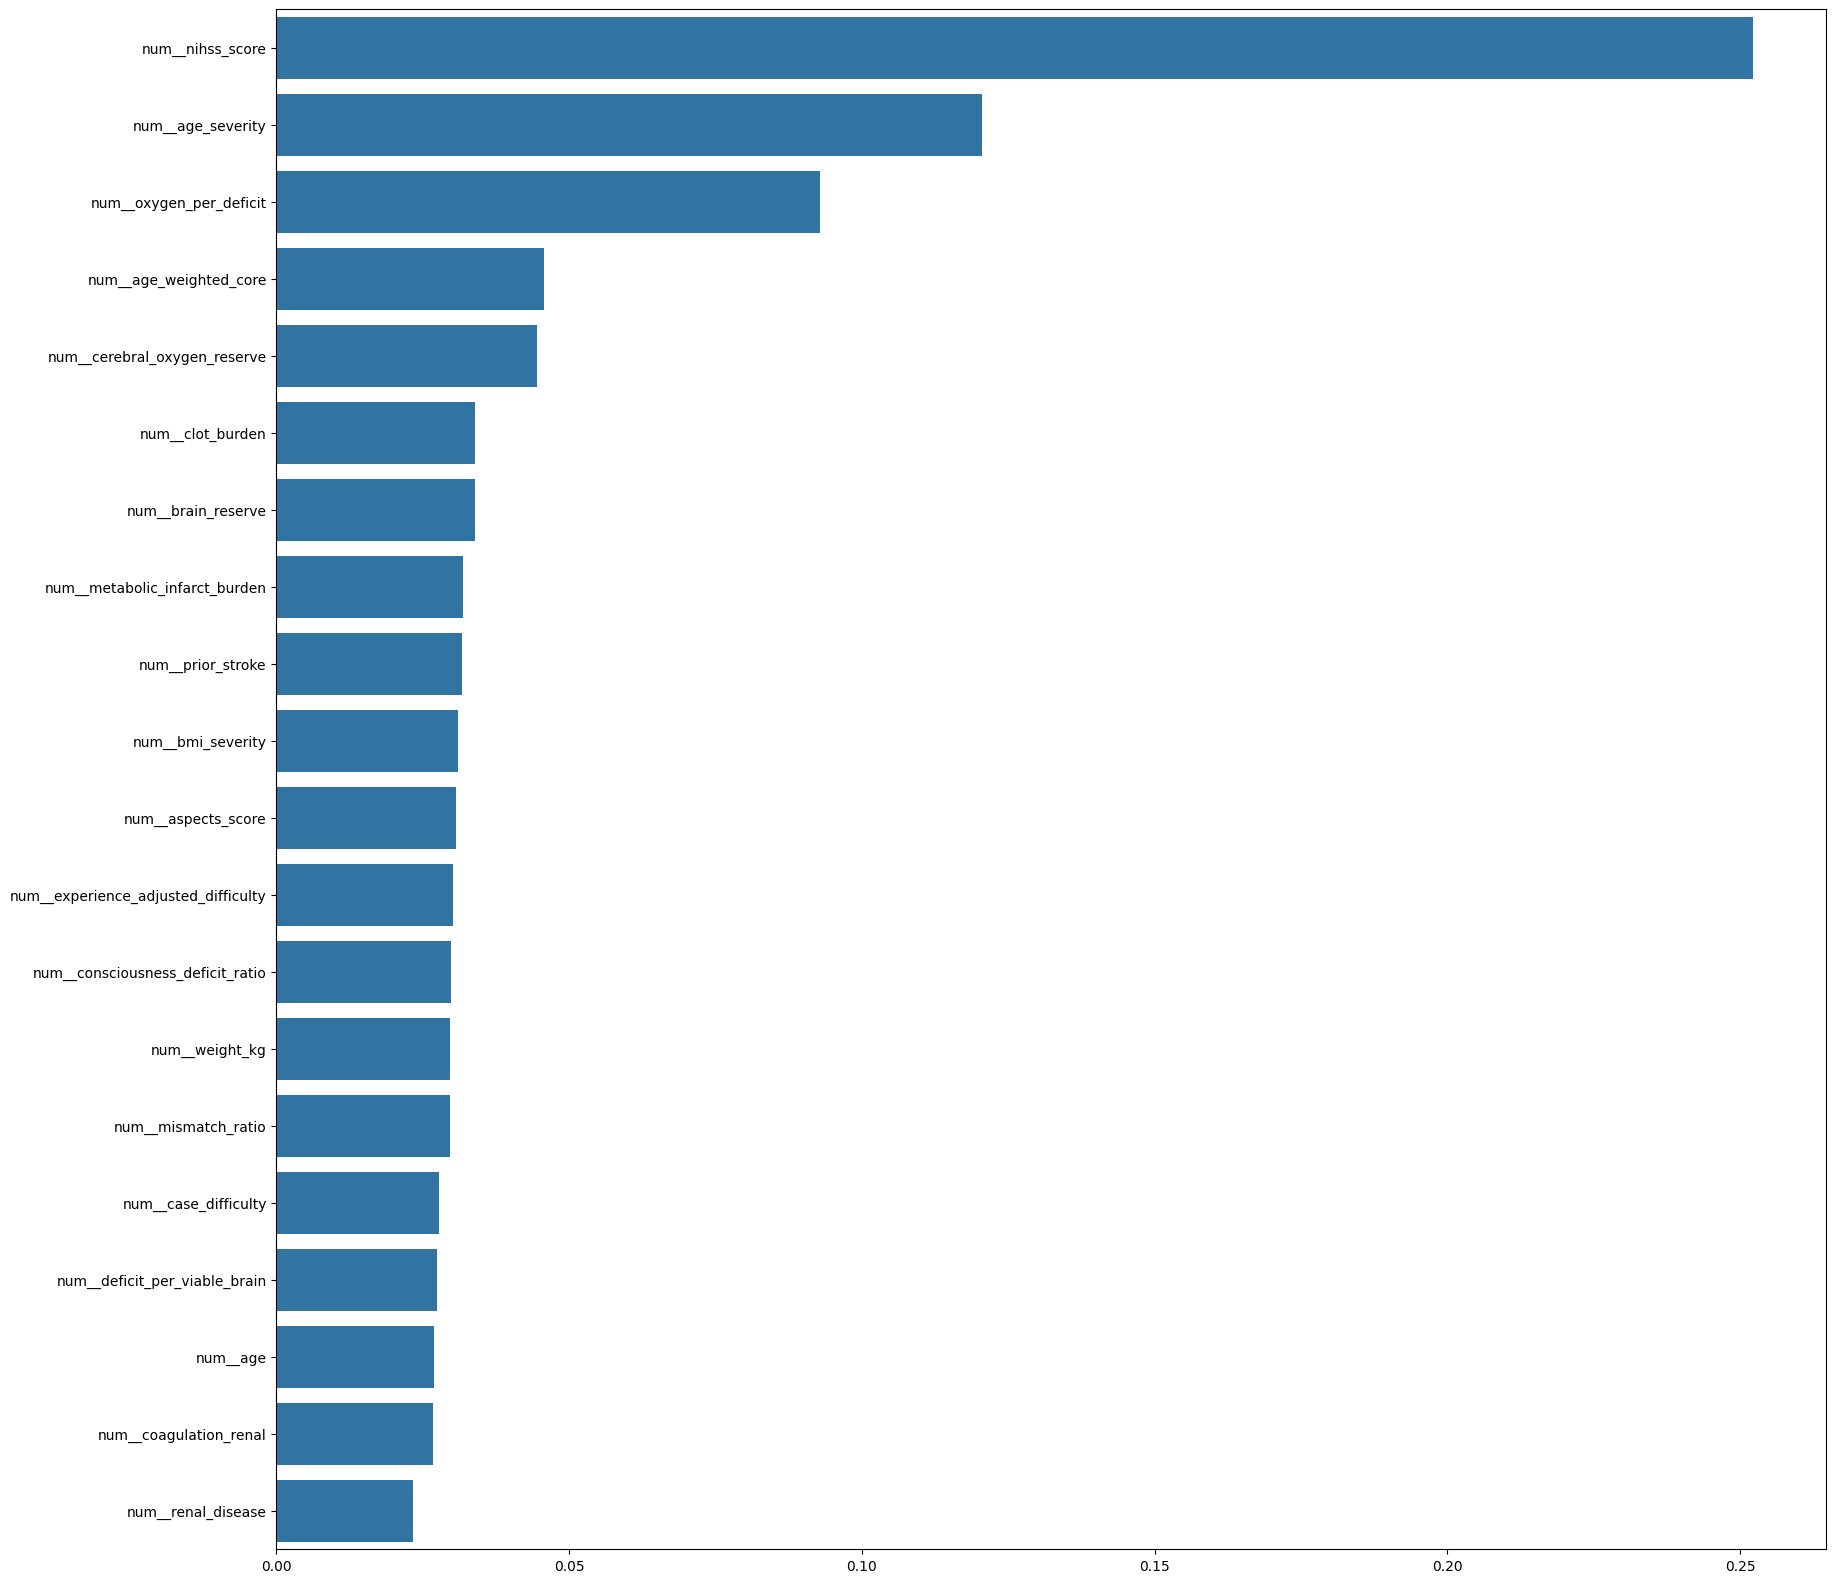

In [111]:
importance
plt.figure(figsize=(20,20))
sns.barplot(data=importance, orient='h')

In [112]:
print(Y.value_counts(normalize=True))

1    0.599667
0    0.400333
Name: proportion, dtype: float64


In [113]:
# Save the full updated DataFrame (original + all new engineered features)
df.to_csv('data_cleaned_version.csv', index=False)
print(f"Saved! Shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")

Saved! Shape: (3000, 85)
Total columns: 85


In [114]:
df.total_procedure_time_min

0        64
1       143
2       109
3        93
4       103
       ... 
2995     90
2996    110
2997    100
2998     99
2999     94
Name: total_procedure_time_min, Length: 3000, dtype: int64